# Анализ тональности текста

Лабораторная работа № 2 по дисциплине «Методы машинного обучения».
Московский Политех, группа 231-329, Арутюнян Ф. Р.

**Как я понял задачу.** Дан набор отзывов на фильмы IMDB с метками positive и negative.
Нужно предобработать тексты, перевести их в числовые признаки и обучить модель, которая
определяет тональность отзыва. Объём выборки задаётся вариантом: мой номер в списке группы 1,
значит беру 10 000 отзывов случайным образом. В конце обязательна таблица с числом
положительных и отрицательных отзывов.

**Данные.** Файл `IMDB_dataset.xlsx` из материалов к работе, переведён в csv: 25 000 отзывов,
поровну положительных и отрицательных.

**Два подхода к решению:**
1. Мешок слов и логистическая регрессия. Текст превращается в вектор частот слов,
   порядок слов теряется.
2. Рекуррентная сеть LSTM. Слова подаются по очереди, сеть хранит внутреннее состояние,
   поэтому порядок слов сохраняется.

**План работы:**
1. Загрузка выборки и разведочный анализ.
2. Предобработка текста.
3. Векторизация: мешок слов и TF-IDF.
4. Логистическая регрессия и её разбор.
5. Рекуррентная сеть LSTM.
6. Сравнение подходов и таблица с числом отзывов по классам.

## 0. Библиотеки и настройки

In [1]:
import os
import re
import time
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, roc_curve, classification_report)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

FIG_DIR = 'figures'
os.makedirs(FIG_DIR, exist_ok=True)

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print('Устройство:', device)


def save_fig(name):
    plt.savefig(os.path.join(FIG_DIR, name), dpi=150, bbox_inches='tight')

Устройство: mps


## 1. Выборка и разведочный анализ

Из 25 000 отзывов беру 10 000 случайным образом с фиксированным `random_state`, как требует вариант.

In [2]:
SAMPLE_SIZE = 10000

full = pd.read_csv('data/imdb_dataset.csv')
print('Всего отзывов в файле:', len(full))
print(full['sentiment'].value_counts().to_dict())

df = full.sample(SAMPLE_SIZE, random_state=RANDOM_STATE).reset_index(drop=True)
df['label'] = (df['sentiment'] == 'positive').astype(int)
print('\nВыборка по варианту:', len(df))
print(df['sentiment'].value_counts().to_dict())
df.head(3)

Всего отзывов в файле: 25000
{'positive': 12500, 'negative': 12500}

Выборка по варианту: 10000
{'negative': 5041, 'positive': 4959}


,review,sentiment,label
0,This movie just stunk. I know that some people...,negative,0
1,The Man in the White Suit is one of those deli...,positive,1
2,Why is impossible to write in french ? Very Ki...,negative,0


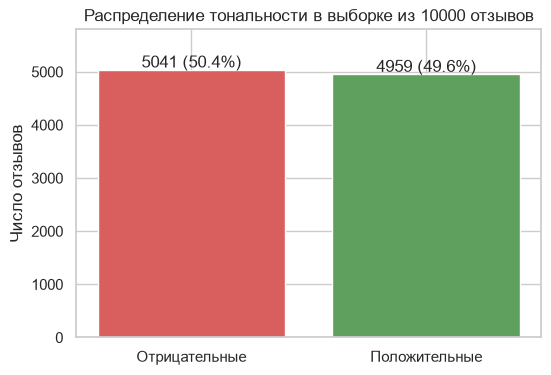

In [3]:
counts = df['sentiment'].value_counts()
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['Отрицательные', 'Положительные'], [counts['negative'], counts['positive']],
       color=['#d95f5f', '#5fa05f'])
for i, v in enumerate([counts['negative'], counts['positive']]):
    ax.text(i, v + 40, f'{v} ({v / len(df):.1%})', ha='center')
ax.set_ylabel('Число отзывов')
ax.set_title(f'Распределение тональности в выборке из {len(df)} отзывов')
ax.set_ylim(0, max(counts) * 1.15)
save_fig('01_class_balance.png')
plt.show()

**Рисунок 1 — Распределение тональности в выборке**

В выборке 5041 отрицательный отзыв и 4959 положительных, разница меньше процента, поэтому accuracy корректна и балансировать классы не нужно.

            mean    50%   min     max
sentiment                            
negative   230.7  174.0   8.0  1522.0
positive   232.2  173.0  16.0  2278.0


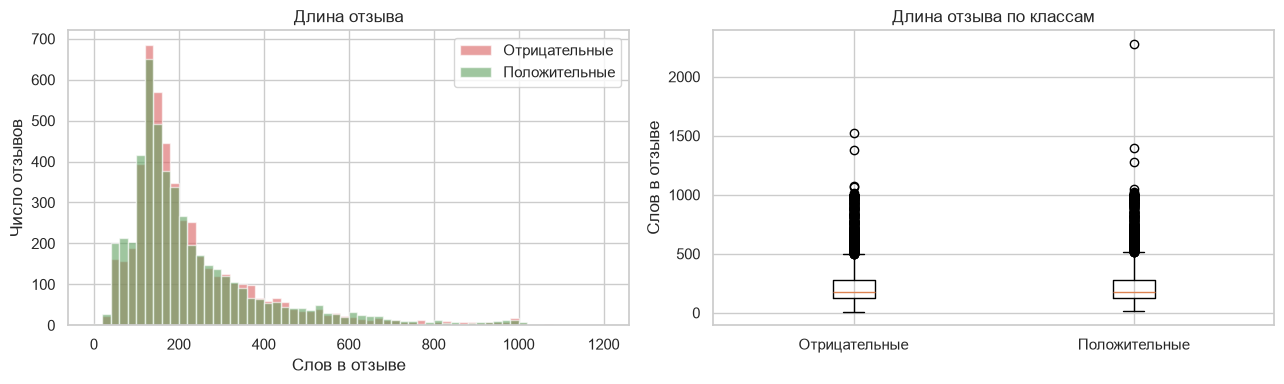

In [4]:
df['n_words'] = df['review'].str.split().str.len()
print(df.groupby('sentiment')['n_words'].describe().round(1)[['mean', '50%', 'min', 'max']])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for label, color, name in [('negative', '#d95f5f', 'Отрицательные'), ('positive', '#5fa05f', 'Положительные')]:
    axes[0].hist(df[df['sentiment'] == label]['n_words'], bins=60, range=(0, 1200),
                 alpha=0.6, color=color, label=name)
axes[0].set_xlabel('Слов в отзыве')
axes[0].set_ylabel('Число отзывов')
axes[0].set_title('Длина отзыва')
axes[0].legend()

axes[1].boxplot([df[df['sentiment'] == 'negative']['n_words'], df[df['sentiment'] == 'positive']['n_words']],
                tick_labels=['Отрицательные', 'Положительные'])
axes[1].set_ylabel('Слов в отзыве')
axes[1].set_title('Длина отзыва по классам')
fig.tight_layout()
save_fig('02_length.png')
plt.show()

**Рисунок 2 — Длина отзывов**

Длина отзывов у классов совпадает: медиана 174 слова у отрицательных и 173 у положительных при максимуме 2278, значит по длине тональность не определить.

## 2. Предобработка текста

Тексты выгружены с сайта, поэтому внутри встречаются html-теги переноса строки `<br />`.
Что делаю:
- перевожу в нижний регистр, иначе «Good» и «good» станут разными признаками;
- убираю html-теги и всё, кроме букв и пробелов;
- склеиваю повторяющиеся пробелы.

Стемминг и лемматизацию не применяю: для английских отзывов выигрыш небольшой, а разбор
ошибок усложняется. Стоп-слова убираю на этапе векторизации встроенным списком sklearn.

In [5]:
TAG_RE = re.compile(r'<[^>]+>')
NON_LETTER_RE = re.compile(r'[^a-z\s]')


def clean(text):
    text = text.lower()
    text = TAG_RE.sub(' ', text)
    text = NON_LETTER_RE.sub(' ', text)
    return ' '.join(text.split())


df['clean'] = df['review'].apply(clean)

print('До:', df.loc[0, 'review'][:200])
print('\nПосле:', df.loc[0, 'clean'][:200])
print('\nСлов до очистки:', int(df['n_words'].sum()),
      'после:', int(df['clean'].str.split().str.len().sum()))

До: This movie just stunk. I know that some people will say that anybody who thinks it is no good "just doesn't get it." I like Wenders in American Friend and Wings of Desire. But this is utter dreck. The

После: this movie just stunk i know that some people will say that anybody who thinks it is no good just doesn t get it i like wenders in american friend and wings of desire but this is utter dreck the main 

Слов до очистки: 2314358 после: 2344551


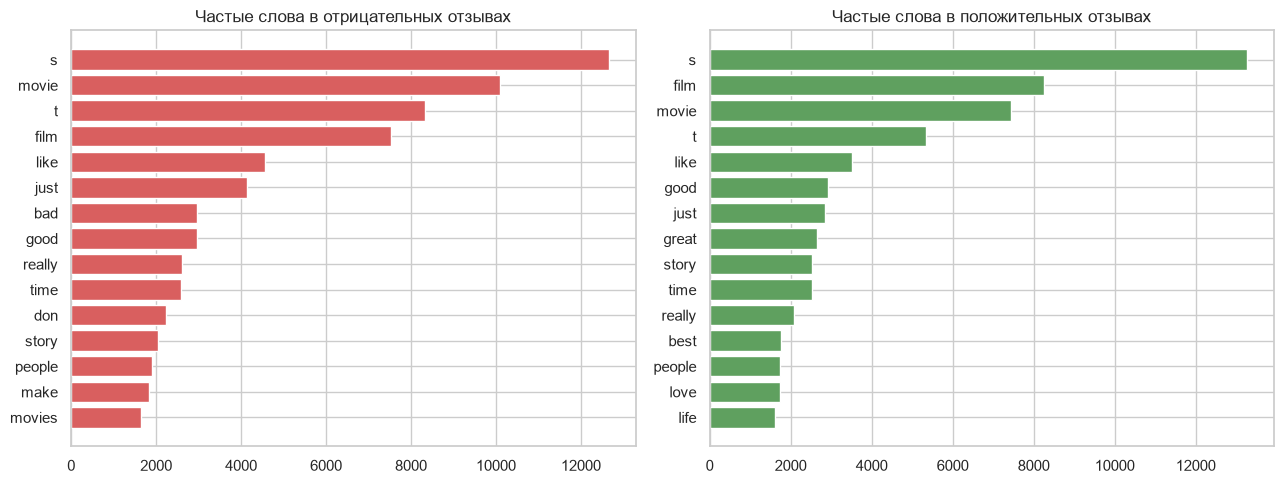

In [6]:
# самые частые слова в каждом классе после удаления стоп-слов
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

def top_words(texts, n=15):
    cnt = pd.Series(' '.join(texts).split()).value_counts()
    cnt = cnt[~cnt.index.isin(ENGLISH_STOP_WORDS)]
    return cnt.head(n)


top_pos = top_words(df[df['label'] == 1]['clean'])
top_neg = top_words(df[df['label'] == 0]['clean'])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].barh(top_neg.index[::-1], top_neg.values[::-1], color='#d95f5f')
axes[0].set_title('Частые слова в отрицательных отзывах')
axes[1].barh(top_pos.index[::-1], top_pos.values[::-1], color='#5fa05f')
axes[1].set_title('Частые слова в положительных отзывах')
fig.tight_layout()
save_fig('03_top_words.png')
plt.show()

**Рисунок 3 — Самые частые слова по классам**

Верх частотности у обоих классов занимают нейтральные слова (movie, film, like) и обрывки сокращений s и t, оценочные слова идут ниже: bad у отрицательных, good, great, best и love у положительных.

## 3. Разбиение и векторизация

Разбиение 75 / 25 со стратификацией. Векторизатор настраиваю только на обучающей части,
иначе словарь будет знать про тестовые отзывы.

**Мешок слов** (`CountVectorizer`): строит словарь из 20 000 самых частых слов и считает,
сколько раз каждое слово встретилось в отзыве. Порядок слов теряется.

**TF-IDF** (`TfidfVectorizer`): та же матрица, но частота слова делится на то, насколько часто
слово встречается во всех отзывах. Слова вроде movie и film получают меньший вес, редкие
и содержательные больший.

In [7]:
X_train_txt, X_test_txt, y_train, y_test = train_test_split(
    df['clean'], df['label'], test_size=0.25, stratify=df['label'], random_state=RANDOM_STATE)

print(f'Обучение {len(X_train_txt)}, тест {len(X_test_txt)}')

bow = CountVectorizer(max_features=20000, stop_words='english')
X_train_bow = bow.fit_transform(X_train_txt)
X_test_bow = bow.transform(X_test_txt)

tfidf = TfidfVectorizer(max_features=20000, stop_words='english', ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train_txt)
X_test_tfidf = tfidf.transform(X_test_txt)

print('Размер матрицы мешка слов:', X_train_bow.shape,
      f'заполнено {X_train_bow.nnz / np.prod(X_train_bow.shape):.3%} ячеек')
print('Размер матрицы TF-IDF:', X_train_tfidf.shape)

Обучение 7500, тест 2500


Размер матрицы мешка слов: (7500, 20000) заполнено 0.414% ячеек
Размер матрицы TF-IDF: (7500, 20000)


## 4. Подход 1: логистическая регрессия

Логистическая регрессия на мешке слов даёт каждому слову вес. Положительный вес означает,
что слово тянет отзыв к классу «положительный», отрицательный наоборот. Такую модель легко
проверить глазами: достаточно посмотреть на слова с самыми большими весами.

In [8]:
def evaluate(name, y_true, y_pred, y_proba):
    return {
        'Модель': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1': f1_score(y_true, y_pred),
        'ROC-AUC': roc_auc_score(y_true, y_proba),
    }


results = []

logreg_bow = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
logreg_bow.fit(X_train_bow, y_train)
p_bow = logreg_bow.predict_proba(X_test_bow)[:, 1]
results.append(evaluate('Мешок слов + логрегрессия', y_test, (p_bow > 0.5).astype(int), p_bow))

logreg_tfidf = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
logreg_tfidf.fit(X_train_tfidf, y_train)
p_tfidf = logreg_tfidf.predict_proba(X_test_tfidf)[:, 1]
results.append(evaluate('TF-IDF + логрегрессия', y_test, (p_tfidf > 0.5).astype(int), p_tfidf))

pd.DataFrame(results).set_index('Модель').round(4)

,Accuracy,Precision,Recall,F1,ROC-AUC
Модель,,,,,
Мешок слов + логрегрессия,0.8636,0.8553,0.8726,0.8639,0.9275
TF-IDF + логрегрессия,0.8736,0.8554,0.8968,0.8756,0.9437


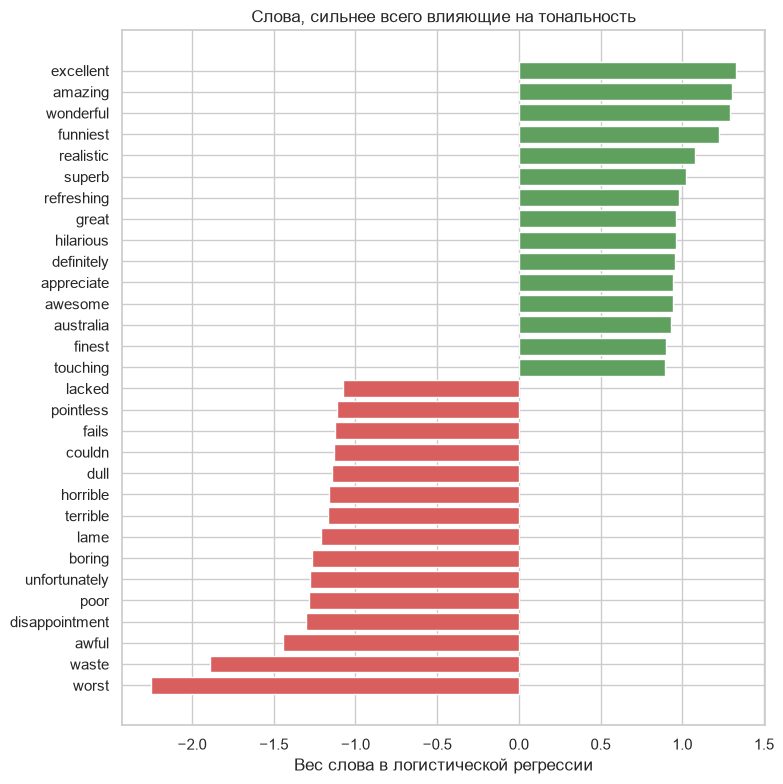

In [9]:
# слова с самыми большими по модулю весами
coefs = pd.Series(logreg_bow.coef_[0], index=bow.get_feature_names_out())
top = pd.concat([coefs.nlargest(15), coefs.nsmallest(15)]).sort_values()

fig, ax = plt.subplots(figsize=(8, 8))
colors = ['#d95f5f' if v < 0 else '#5fa05f' for v in top.values]
ax.barh(top.index, top.values, color=colors)
ax.set_xlabel('Вес слова в логистической регрессии')
ax.set_title('Слова, сильнее всего влияющие на тональность')
fig.tight_layout()
save_fig('04_coefficients.png')
plt.show()

**Рисунок 4 — Слова с наибольшими весами в логистической регрессии**

Самые сильные отрицательные веса у worst (−2,2), waste (−1,9) и awful (−1,4), самые сильные положительные у excellent, amazing и wonderful (около +1,3). Слово australia среди положительных показывает, что на 7500 отзывов часть весов случайна.

## 5. Подход 2: рекуррентная сеть LSTM

Мешок слов не видит порядок слов, поэтому «not good at all» и «good» для него похожи.
Рекуррентная сеть читает отзыв по словам и хранит состояние, в котором накапливается смысл
прочитанного. LSTM это вариант рекуррентной ячейки с тремя вентилями: забывания, входным
и выходным. Вентили решают, что стереть из состояния, что записать и что отдать наружу,
поэтому сеть помнит слова на длинных отзывах лучше простой RNN.

Подготовка данных для сети:
- словарь из 20 000 самых частых слов обучающей выборки, остальные слова заменяются на `<unk>`;
- каждый отзыв обрезается или дополняется нулями до 300 слов;
- слова превращаются в векторы обучаемым слоем Embedding размерности 128;
- вместе с отзывом сети передаётся его настоящая длина.

Длина нужна из-за дополнения нулями. Если этого не сделать, сеть после последнего слова отзыва
прогонит ещё сотню пустых шагов, и от смысла в последнем состоянии ничего не останется.
Функция `pack_padded_sequence` говорит LSTM, где заканчивается каждый отзыв.
Без неё сеть у меня давала accuracy 0,507, то есть работала на уровне подбрасывания монетки.

In [10]:
MAX_LEN = 300
VOCAB_SIZE = 20000

counter = pd.Series(' '.join(X_train_txt).split()).value_counts()
vocab = {w: i + 2 for i, w in enumerate(counter.head(VOCAB_SIZE - 2).index)}  # 0 = паддинг, 1 = <unk>
print('Слов в словаре:', len(vocab) + 2)


def encode(text):
    ids = [vocab.get(w, 1) for w in text.split()[:MAX_LEN]]
    return ids + [0] * (MAX_LEN - len(ids))


def lengths_of(texts):
    return torch.tensor([max(1, min(len(t.split()), MAX_LEN)) for t in texts], dtype=torch.long)


X_train_seq = torch.tensor([encode(t) for t in X_train_txt], dtype=torch.long)
X_test_seq = torch.tensor([encode(t) for t in X_test_txt], dtype=torch.long)
len_train, len_test = lengths_of(X_train_txt), lengths_of(X_test_txt)
y_train_t = torch.tensor(y_train.values, dtype=torch.float32)
y_test_t = torch.tensor(y_test.values, dtype=torch.float32)

train_dl = DataLoader(TensorDataset(X_train_seq, len_train, y_train_t), batch_size=64, shuffle=True)
test_dl = DataLoader(TensorDataset(X_test_seq, len_test, y_test_t), batch_size=64)
print('Форма входа сети:', X_train_seq.shape)
print('Средняя длина отзыва в словах:', int(len_train.float().mean()))

Слов в словаре: 20000


Форма входа сети: torch.Size([7500, 300])
Средняя длина отзыва в словах: 190


In [11]:
class LSTMSentiment(nn.Module):
    def __init__(self, vocab_size=VOCAB_SIZE, emb_dim=128, hidden=128):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.lstm = nn.LSTM(emb_dim, hidden, batch_first=True)
        self.drop = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden, 1)

    def forward(self, x, lengths):
        e = self.emb(x)
        # упаковка: LSTM не будет крутить пустые шаги после конца отзыва
        packed = nn.utils.rnn.pack_padded_sequence(e, lengths.cpu(), batch_first=True, enforce_sorted=False)
        out, (h, c) = self.lstm(packed)
        return self.fc(self.drop(h[-1])).squeeze(1)


lstm = LSTMSentiment().to(device)
print(f'Обучаемых параметров: {sum(p.numel() for p in lstm.parameters()):,}')

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(lstm.parameters(), lr=1e-3)

history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}
EPOCHS = 8
t0 = time.time()
for ep in range(1, EPOCHS + 1):
    for mode, loader in [('train', train_dl), ('test', test_dl)]:
        lstm.train(mode == 'train')
        tot_loss, correct, total = 0.0, 0, 0
        for xb, lb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            with torch.set_grad_enabled(mode == 'train'):
                out = lstm(xb, lb)
                loss = criterion(out, yb)
            if mode == 'train':
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            tot_loss += loss.item() * yb.size(0)
            correct += ((out > 0).float() == yb).sum().item()
            total += yb.size(0)
        history[f'{mode}_loss'].append(tot_loss / total)
        history[f'{mode}_acc'].append(correct / total)
    print(f"эпоха {ep}: потери {history['train_loss'][-1]:.3f}/{history['test_loss'][-1]:.3f}, "
          f"точность {history['train_acc'][-1]:.3f}/{history['test_acc'][-1]:.3f}")
print(f'обучение заняло {time.time() - t0:.0f} с')

Обучаемых параметров: 2,692,225


эпоха 1: потери 0.677/0.654, точность 0.565/0.607


эпоха 2: потери 0.610/0.687, точность 0.675/0.579


эпоха 3: потери 0.569/0.627, точность 0.707/0.644


эпоха 4: потери 0.533/0.867, точность 0.738/0.593


эпоха 5: потери 0.448/0.569, точность 0.800/0.762


эпоха 6: потери 0.453/0.575, точность 0.789/0.714


эпоха 7: потери 0.390/0.571, точность 0.829/0.713


эпоха 8: потери 0.332/0.565, точность 0.866/0.740
обучение заняло 229 с


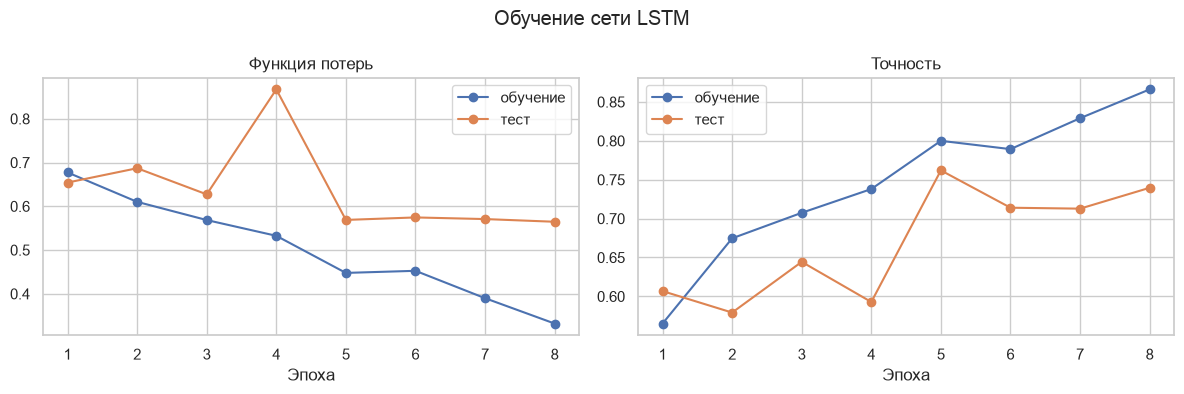

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ep = range(1, EPOCHS + 1)
axes[0].plot(ep, history['train_loss'], 'o-', label='обучение')
axes[0].plot(ep, history['test_loss'], 'o-', label='тест')
axes[0].set_title('Функция потерь')
axes[0].set_xlabel('Эпоха')
axes[0].legend()
axes[1].plot(ep, history['train_acc'], 'o-', label='обучение')
axes[1].plot(ep, history['test_acc'], 'o-', label='тест')
axes[1].set_title('Точность')
axes[1].set_xlabel('Эпоха')
axes[1].legend()
fig.suptitle('Обучение сети LSTM')
fig.tight_layout()
save_fig('05_lstm_training.png')
plt.show()

**Рисунок 5 — Кривые обучения сети LSTM**

Потери на обучении падают с 0,677 до 0,332, а на тесте после пятой эпохи держатся около 0,57 и точность не растёт: сеть запоминает обучающие отзывы вместо того, чтобы обобщать.

In [13]:
lstm.eval()
probs = []
with torch.no_grad():
    for xb, lb, _ in test_dl:
        probs.append(torch.sigmoid(lstm(xb.to(device), lb)).cpu().numpy())
p_lstm = np.concatenate(probs)
results.append(evaluate('LSTM', y_test, (p_lstm > 0.5).astype(int), p_lstm))

res_df = pd.DataFrame(results).set_index('Модель').sort_values('Accuracy', ascending=False)
res_df.round(4)

,Accuracy,Precision,Recall,F1,ROC-AUC
Модель,,,,,
TF-IDF + логрегрессия,0.8736,0.8554,0.8968,0.8756,0.9437
Мешок слов + логрегрессия,0.8636,0.8553,0.8726,0.8639,0.9275
LSTM,0.7396,0.7416,0.7290,0.7353,0.8072


## 6. Сравнение подходов

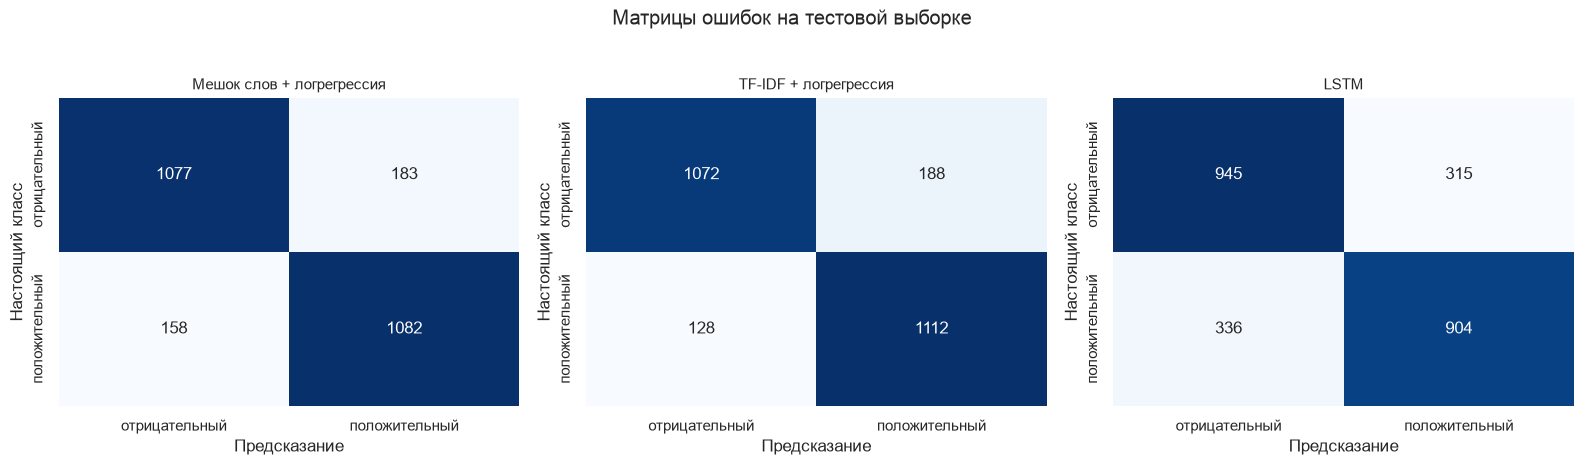

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (name, proba) in zip(axes, [('Мешок слов + логрегрессия', p_bow),
                                    ('TF-IDF + логрегрессия', p_tfidf),
                                    ('LSTM', p_lstm)]):
    cm = confusion_matrix(y_test, (proba > 0.5).astype(int))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['отрицательный', 'положительный'],
                yticklabels=['отрицательный', 'положительный'])
    ax.set_title(name, fontsize=11)
    ax.set_xlabel('Предсказание')
    ax.set_ylabel('Настоящий класс')
fig.suptitle('Матрицы ошибок на тестовой выборке', y=1.03)
fig.tight_layout()
save_fig('06_confusion.png')
plt.show()

**Рисунок 6 — Матрицы ошибок трёх моделей**

Из 2500 тестовых отзывов TF-IDF ошибается 316 раз, мешок слов 341, LSTM 651, причём сеть путает оба класса примерно поровну.

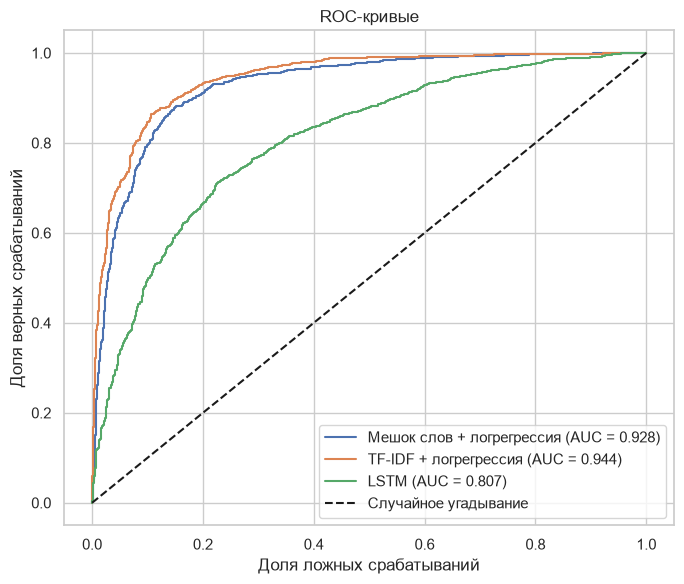

In [15]:
fig, ax = plt.subplots(figsize=(7, 6))
for name, proba in [('Мешок слов + логрегрессия', p_bow), ('TF-IDF + логрегрессия', p_tfidf), ('LSTM', p_lstm)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc_score(y_test, proba):.3f})')
ax.plot([0, 1], [0, 1], 'k--', label='Случайное угадывание')
ax.set_xlabel('Доля ложных срабатываний')
ax.set_ylabel('Доля верных срабатываний')
ax.set_title('ROC-кривые')
ax.legend()
fig.tight_layout()
save_fig('07_roc.png')
plt.show()

**Рисунок 7 — ROC-кривые трёх моделей**

ROC-AUC у TF-IDF 0,944, у мешка слов 0,928, у LSTM 0,807, то есть ранжирует отзывы линейная модель заметно лучше сети.

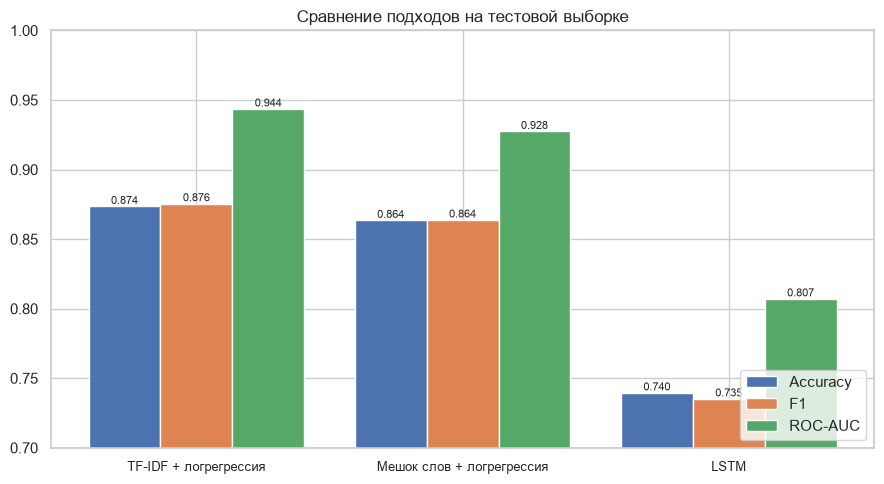

In [16]:
fig, ax = plt.subplots(figsize=(9, 5))
plot_df = res_df[['Accuracy', 'F1', 'ROC-AUC']]
x = np.arange(len(plot_df))
width = 0.27
for i, metric in enumerate(plot_df.columns):
    bars = ax.bar(x + (i - 1) * width, plot_df[metric], width, label=metric)
    ax.bar_label(bars, fmt='%.3f', fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(plot_df.index, fontsize=9)
ax.set_ylim(0.7, 1.0)
ax.set_title('Сравнение подходов на тестовой выборке')
ax.legend(loc='lower right')
fig.tight_layout()
save_fig('08_comparison.png')
plt.show()

**Рисунок 8 — Сравнение подходов по метрикам**

TF-IDF лучший по всем трём метрикам (accuracy 0,874, F1 0,876, ROC-AUC 0,944), LSTM отстаёт на 13,4 процентного пункта accuracy.

## 7. Итоговая таблица по числу отзывов

Обязательный по заданию результат: сколько в выборке положительных и отрицательных отзывов
и как их распределила лучшая модель.

In [17]:
best_name = res_df.index[0]
best_proba = {'Мешок слов + логрегрессия': p_bow, 'TF-IDF + логрегрессия': p_tfidf, 'LSTM': p_lstm}[best_name]
best_pred = (best_proba > 0.5).astype(int)

summary = pd.DataFrame({
    'Вся выборка (10 000)': df['label'].value_counts().sort_index().values,
    'Обучающая часть': pd.Series(y_train).value_counts().sort_index().values,
    'Тестовая часть': pd.Series(y_test).value_counts().sort_index().values,
    f'Предсказано моделью «{best_name}»': pd.Series(best_pred).value_counts().sort_index().values,
}, index=['Отрицательные', 'Положительные'])
summary.loc['Всего'] = summary.sum()
print(f'Лучшая модель: {best_name}\n')
summary

Лучшая модель: TF-IDF + логрегрессия



,Вся выборка (10 000),Обучающая часть,Тестовая часть,Предсказано моделью «TF-IDF + логрегрессия»
Отрицательные,5041,3781,1260,1200
Положительные,4959,3719,1240,1300
Всего,10000,7500,2500,2500


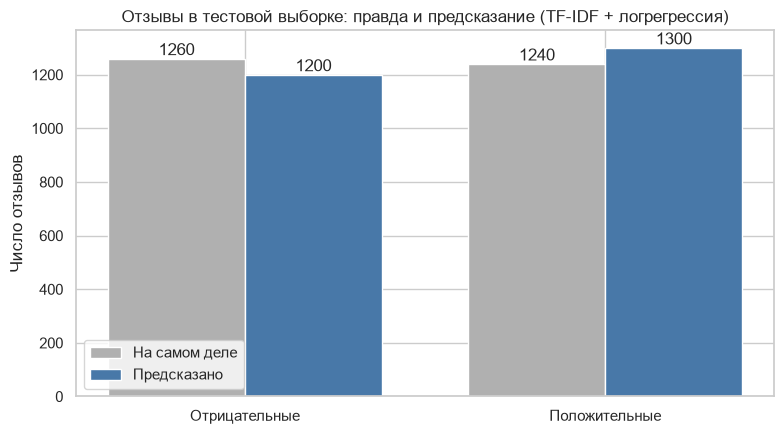

In [18]:
fig, ax = plt.subplots(figsize=(8, 4.5))
labels = ['Отрицательные', 'Положительные']
x = np.arange(2)
width = 0.38
bars1 = ax.bar(x - width / 2, summary.loc[labels, 'Тестовая часть'], width,
               label='На самом деле', color='#b0b0b0')
bars2 = ax.bar(x + width / 2, summary.loc[labels, f'Предсказано моделью «{best_name}»'], width,
               label='Предсказано', color='#4878a8')
ax.bar_label(bars1)
ax.bar_label(bars2)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Число отзывов')
ax.set_title(f'Отзывы в тестовой выборке: правда и предсказание ({best_name})')
ax.legend()
fig.tight_layout()
save_fig('09_counts.png')
plt.show()

**Рисунок 9 — Число отзывов по классам: правда и предсказание**

Модель насчитала 1300 положительных отзывов против 1240 настоящих, то есть 60 отзывов сверх меры отнесла к положительным.

In [19]:
print(classification_report(y_test, best_pred, target_names=['отрицательные', 'положительные'], digits=4))

# несколько отзывов, на которых лучшая модель ошиблась
errors = np.where(best_pred != y_test.values)[0][:3]
for k in errors:
    text = X_test_txt.iloc[k]
    print(f"\nнастоящий: {'положительный' if y_test.iloc[k] else 'отрицательный'}, "
          f"вероятность положительного {best_proba[k]:.2f}")
    print(text[:300], '...')

               precision    recall  f1-score   support

отрицательные     0.8933    0.8508    0.8715      1260
положительные     0.8554    0.8968    0.8756      1240

     accuracy                         0.8736      2500
    macro avg     0.8744    0.8738    0.8736      2500
 weighted avg     0.8745    0.8736    0.8736      2500


настоящий: отрицательный, вероятность положительного 0.52
almost as tedious to watch as it was to read evening is a gorgeously produced failure until meryl streep walks in and quietly shows her other cast members how to act this kind of stuff vanessa redgrave is shockingly off in her role as the dying ann and claire danes is a cipher perhaps if vanessa and ...

настоящий: отрицательный, вероятность положительного 0.65
i watched dvd only the program proper may have minutes of good information otherwise it s snotty putdowns of religious people it s as if director brian flemming only recently discovered both atheism and sarcasm and feels with these tools he can

## 8. Выводы

1. **Выборка по варианту.** Из 25 000 отзывов взято 10 000: 5041 отрицательный и 4959 положительных.
   Разбиение 75 / 25 со стратификацией, тест 2500 отзывов.

2. **Лучший результат у TF-IDF с логистической регрессией:** accuracy 0,8736, precision 0,8554,
   recall 0,8968, F1 0,8756, ROC-AUC 0,9437. Мешок слов немного хуже (0,8636), потому что TF-IDF
   занижает вес слов movie и film, которые встречаются у обоих классов, и добавляет пары слов.

3. **Рекуррентная сеть LSTM даёт 0,7396** и ROC-AUC 0,8072, это на 13,4 процентного пункта хуже
   линейной модели. Причины видны по кривым обучения: 7500 отзывов мало, чтобы обучить с нуля
   2,7 млн параметров вместе с векторами слов, и после пятой эпохи сеть переобучается.
   Для тональности отзывов важен в основном набор оценочных слов, а его мешок слов ловит напрямую.

4. **Важность правильной работы с длиной.** Сначала я подавал в сеть отзывы, дополненные нулями
   до 300 слов, и брал последнее состояние: сеть давала accuracy 0,507, то есть не работала вовсе.
   После `pack_padded_sequence`, которая останавливает LSTM на настоящей длине отзыва,
   точность поднялась до 0,7396.

5. **Что видно по весам модели.** Логистическая регрессия сама находит оценочную лексику:
   worst, waste, awful тянут отзыв к отрицательному классу, excellent, amazing, wonderful
   к положительному. Отдельные случайные слова в верхушке весов говорят, что выборки в 7500 отзывов
   для устойчивых весов маловато.

6. **Обязательная таблица по числу отзывов** приведена в разделе 7: в выборке 5041 отрицательный
   и 4959 положительных, в тесте 1260 и 1240, лучшая модель насчитала 1200 и 1300.

7. **Что улучшило бы результат:** предобученные векторы слов вместо обучения с нуля
   (это я проверяю в практической работе № 5), больше данных для сети, двунаправленная LSTM,
   подбор порога и регуляризации.